# Model Evaluation Metrics 


# Cell 1 - Install Required Libraries

Run this cell first in Google Colab.


In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Dataset and preprocessing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)


# Load Dataset

We are using the Breast Cancer dataset from scikit-learn.

## Why this dataset?
It is a clean binary classification dataset and very good for teaching model evaluation.
The target has two classes:
- 0 = malignant
- 1 = benign


In [2]:
# Load the dataset
data = load_breast_cancer()

# Convert features into a pandas DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

# Convert target into a pandas Series
y = pd.Series(data.target, name="target")

# Display dataset information
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:", data.target_names)

# Display the first 5 rows
X.head()


Feature shape: (569, 30)
Target shape: (569,)

Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Explore the Dataset


In [3]:
data.feature_names
data.target_names


array(['malignant', 'benign'], dtype='<U9')

In [4]:
# Check basic information
print("First 5 target values:")
print(y.head())

print("\nClass distribution:")
print(y.value_counts())

print("\nMissing values in each column:")
print(X.isnull().sum().sum())


First 5 target values:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values in each column:
0


# Split Data into Training and Testing Sets


In [5]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training feature shape: (455, 30)
Testing feature shape: (114, 30)
Training target shape: (455,)
Testing target shape: (114,)


# Scale the Features

In [6]:
# Create the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")


Scaling completed successfully.


In [7]:
# Create the machine learning models
log_model = LogisticRegression(max_iter=5000)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

print("Models created.")


Models created.


# Cell 8 - Train Logistic Regression

We train Logistic Regression using scaled data.


In [8]:
# Train Logistic Regression
log_model.fit(X_train_scaled, y_train)

# Predict class labels
y_pred_log = log_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed.")


Logistic Regression training completed.


# Evaluate Logistic Regression

We calculate:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC


In [9]:
# Evaluate Logistic Regression
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall   :", round(log_recall, 4))
print("F1-Score :", round(log_f1, 4))
print("ROC-AUC  :", round(log_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Results
---------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9954

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Confusion Matrix for Logistic Regression



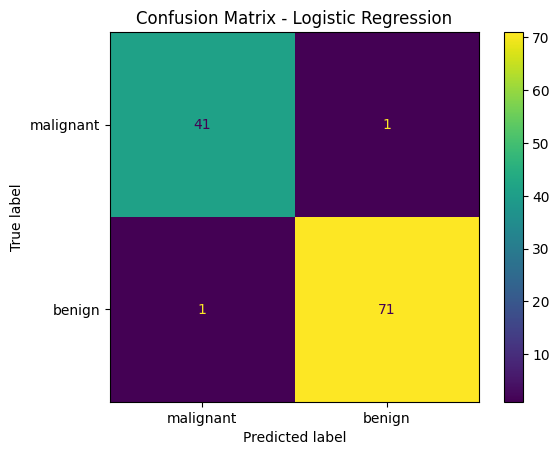

In [10]:
# Create confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=data.target_names)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# Train and Evaluate KNN


In [11]:
# Train KNN model
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate KNN
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN Results")
print("-----------")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-Score :", round(knn_f1, 4))
print("ROC-AUC  :", round(knn_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Results
-----------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655
ROC-AUC  : 0.9788

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# Confusion Matrix for KNN


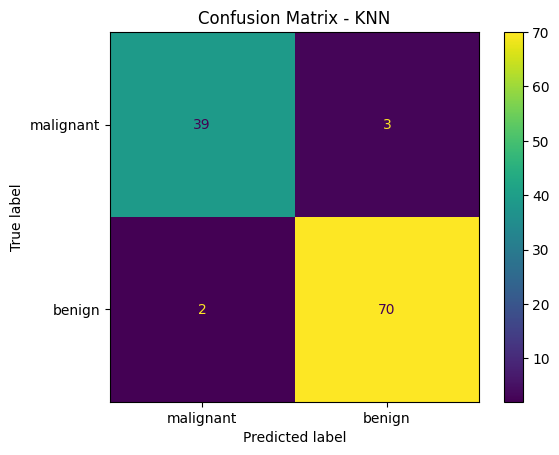

In [12]:
# Create confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=data.target_names)
disp.plot()
plt.title("Confusion Matrix - KNN")
plt.show()


# Train and Evaluate Random Forest

In [13]:
# Train Random Forest on original unscaled training data
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
---------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655
ROC-AUC  : 0.9931

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# Confusion Matrix for Random Forest


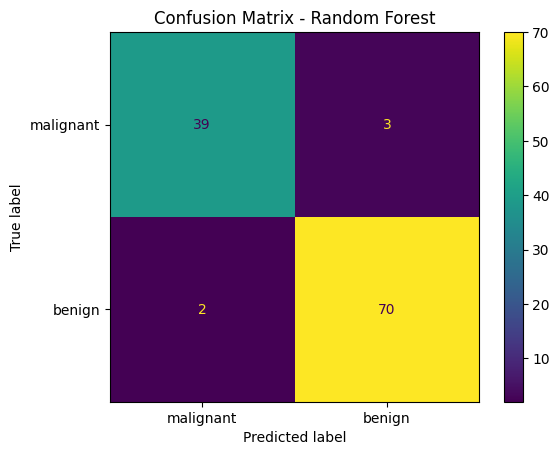

In [14]:
# Create confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=data.target_names)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


# Compare All Models in One Table




In [15]:
# Create a comparison table for all models
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "Accuracy": [log_accuracy, knn_accuracy, rf_accuracy],
    "Precision": [log_precision, knn_precision, rf_precision],
    "Recall": [log_recall, knn_recall, rf_recall],
    "F1-Score": [log_f1, knn_f1, rf_f1],
    "ROC-AUC": [log_auc, knn_auc, rf_auc]
})

comparison_df = comparison_df.round(4)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,KNN,0.9561,0.9589,0.9722,0.9655,0.9788
2,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931


# Plot ROC Curves



<Figure size 800x600 with 0 Axes>

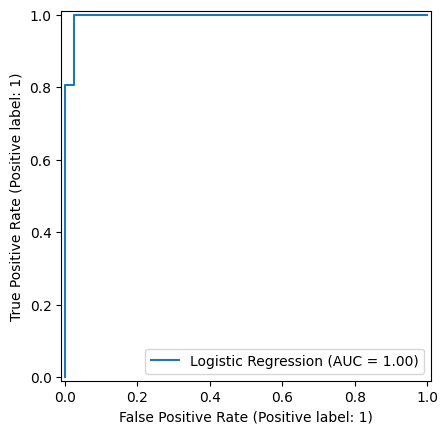

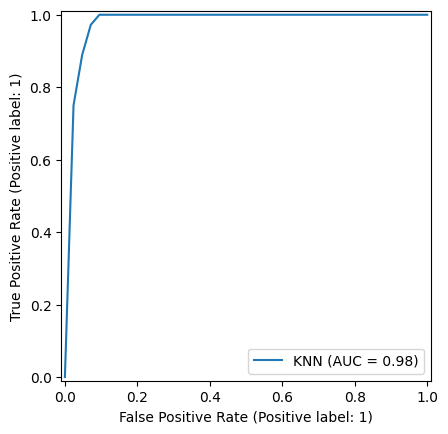

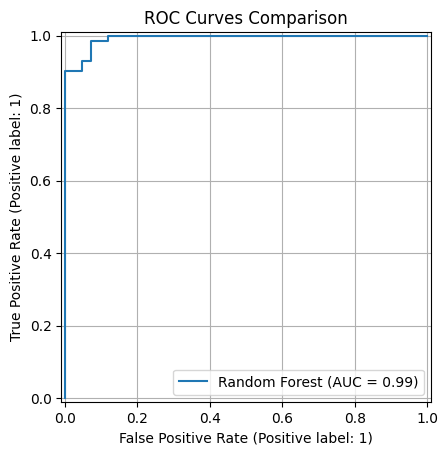

In [16]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_knn, name="KNN")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")

plt.title("ROC Curves Comparison")
plt.grid(True)
plt.show()


# Best Model Decision

In [17]:
# Find the model with highest ROC-AUC
best_model_row = comparison_df.loc[comparison_df["ROC-AUC"].idxmax()]
print("Best model based on ROC-AUC:")
print(best_model_row)


Best model based on ROC-AUC:
Model        Logistic Regression
Accuracy                  0.9825
Precision                 0.9861
Recall                    0.9861
F1-Score                  0.9861
ROC-AUC                   0.9954
Name: 0, dtype: object
